In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import block_diag
from scipy.signal import savgol_filter
from scipy.signal import detrend
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler as minmax_scaler
from sklearn.preprocessing import StandardScaler as std_scaler

import utilities as utils

In [2]:
# --! cavity simulation ------------------------------------------------------!

def make_a_m(w, q):
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q]])

def make_b_m(k, w): 
    return np.array([
        [0              ],
        [-k*np.square(w)]])

def cavity_fn(t, x):
    """
    Executes the logic of cavity differential equations. Input parameters ``t``
    and ``x`` are time and state, respectively.
    """

    # --! current state of a cavity field: real and imaginary components
    x_rf = np.array(x[:2]).reshape((-1, 1))

    # --! current states of all mechanical modes: displacements and velocities
    x_m = np.array(x[2:]).reshape((-1, 1))

    # --! input to cavity field: real and imaginary parts of a generator voltage
    u_rf = np.zeros((2, 1))
    if pctr_on_rf:
        # --! proportional control is on, so calculate an actuation signal u
        r_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

        e_rf = r_rf - x_rf

        u_rf = K_rf * e_rf
    else:
        # --! proportional control is off, so our setpoint becomes our actuation signal
        u_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

    # --! input to mechanical mode: accelerating field gradient squared
    grad = np.sqrt(np.square(x_rf[0]) + np.square(x_rf[1])) # todo: add division by cavity length
    u_m = np.square(grad)

    # --! update detuning in cavity system dynamics
    disp_m = np.sum([x_m[2*i] for i in range(modes_m_n)])
    a_rf[0, 1] = -disp_m
    a_rf[1, 0] =  disp_m

    # --! create an additional instance of mechanical matrix B and split it into
    # --! per-mode submatrices
    b_m_var  = np.copy(b_m)
    bs_m_var = np.split(b_m_var, b_m_var.shape[0] // 2, axis=0)

    # --! split mechanical time boundary array into per-mode parts
    ts_m = np.split(t_m, t_m.shape[0], axis=0) # split into rows

    for mat, timespan in zip(bs_m_var, ts_m):
        if not (timespan[0, 0] <= t and t < timespan[0, 1]):
            mat[:] = 0.

    # --! calculate derivatives
    dx_rf = a_rf @ x_rf + b_rf    @ u_rf
    dx_m  = a_m  @ x_m  + b_m_var * u_m

    return np.array([
        *dx_rf.flatten(),
        *dx_m.flatten()])

def sim_detuning(params):
    """
    Simulate cavity resonance detuning by solving the cavity differential equation.
    The equation is parameterized using ``params``.
    """
    f_m = params['f_m']
    q_m = params['q_m']

    k_m = np.ones_like(f_m) * 2 * np.pi * 1. # coupling with units (2 * pi * Hz) / (MV/m)^2
    w_m = 2 * np.pi * f_m

    global modes_m_n
    modes_m_n = len(f_m)
    print(f'inf >> number of mechanical modes specified: {modes_m_n}')

    # --! assemble mechanical system and input matrices, A and B
    global a_m
    global b_m
    a_m = block_diag(*[make_a_m(w, q) for w, q in zip(w_m, q_m)])
    b_m = np.concatenate([make_b_m(k, w) for k, w in zip(k_m, w_m)], axis=0)

    # --! define timing parameters
    t_span = [0, params['t_rf_n'] * t_rf]
    dt     = params['dt']
    t      = np.arange(t_span[0], t_span[1], dt)

    # --! create a mechanical time boundary matrix, where
    # --! 'dont care' parameter -1 is replaced
    # --! by the actual time boundaries
    global t_m
    t_m    = params['t_m']
    for timespan in np.split(t_m, t_m.shape[0], axis=0): # split into rows
        if timespan[0, 0] == -1:
            timespan[0, 0] = t[0]
        if timespan[0, 1] == -1:
            timespan[0, 1] = t[-1]

    # --! every mechanical mode has two states:
    # --! 1. displacement
    # --! 2. velocity
    modes_m = np.zeros(modes_m_n * 2)

    # --! define zero initial conditions
    x0 = [
        0,         # cavity field real
        0,         # cavity field imaginary
        *modes_m ] # all mechanical modes

    # --! simulate
    return solve_ivp(cavity_fn, t_span, x0, method='RK45', t_eval=t)

# --! static rf parameters for simulation ------------------------------------!

q_rf     = 4e7 # loaded quality factor

f_rf     = 1.3e9
w_rf     = 2 * np.pi * f_rf
w_hbw_rf = w_rf/2/q_rf
f_hbw_rf = w_hbw_rf/2/np.pi
t_rf     = round(1/f_hbw_rf, 2)

# generator voltage
v_rf = [10., 0.]

pctr_on_rf = True
K_rf = 100. # proportional controller gain

a_rf = np.array([
    [-w_hbw_rf,  0.      ],
    [ 0.,       -w_hbw_rf]])

b_rf = np.array([
    [w_hbw_rf, 0       ],
    [0,        w_hbw_rf]])

print(f'inf >> half-bandwidth of this radio frequency cavity is {f_hbw_rf:.2f} Herz')
print(f'inf >> cavity filling time is {t_rf:.2f} seconds')

# --! placeholders for mechanical parameters that are accessed from sim_detuning and cavity_fn
modes_m_n = 0
a_m       = 0
b_m       = 0
t_m       = 0

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


inf >> number of mechanical modes specified: 1
inf >> time step for simulation is 0.0010
inf >> number of time steps is 1020
inf >> starting index to skip a transient process is 10
inf >> scaled states shape is (1010, 1)


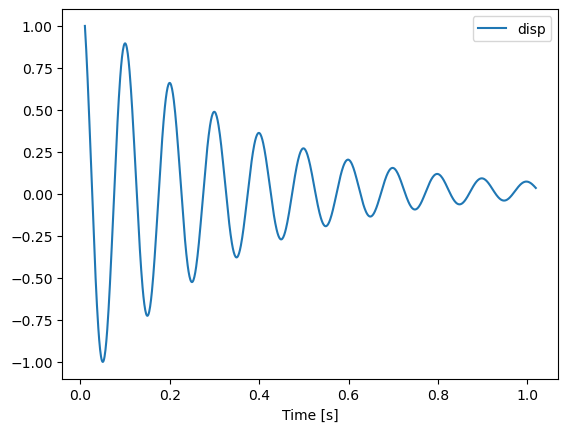

In [3]:
# --! simulate with parameters -----------------------------------------------!

sim_params = {
    'f_m'    : np.array([10.]), # 10, 24
    'q_m'    : np.array([10.]), # 20, 5
    't_m'    : np.array([[-1., -1.]]), # [dont care, dont care]
    't_rf_n' : 17,
    'dt'     : 0.001,
}

y10 = sim_detuning(sim_params)

print(f'inf >> time step for simulation is {sim_params['dt']:.4f}')
print(f'inf >> number of time steps is {len(y10.t)}')

# --! condition simulated data -----------------------------------------------!

# --! sum detuning
disp_m10 = np.zeros_like(y10.y[2])
for i in range(modes_m_n):
    disp_m10 = disp_m10 + y10.y[2 + 2*i]

# --! we want to skip the transient process of an RF cavity when scaling data,
# --! so we specify the start
#
# --! we also want to omit frequency on-off artifacts, so we specify the end
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# --! scale states
x_m10      = np.vstack([disp_m10[start_i:]]).T
x_scaler   = minmax_scaler(feature_range=(-1, 1))
x_m10_sca  = x_scaler.fit_transform(x_m10)

print(f'inf >> scaled states shape is {x_m10_sca.shape}')

plt.figure()
plt.plot(y10.t[start_i:], x_m10_sca[:, 0], label='disp')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

inf >> number of mechanical modes specified: 1
inf >> time step for simulation is 0.0010
inf >> number of time steps is 1020
inf >> starting index to skip a transient process is 10
inf >> scaled states shape is (1010, 1)


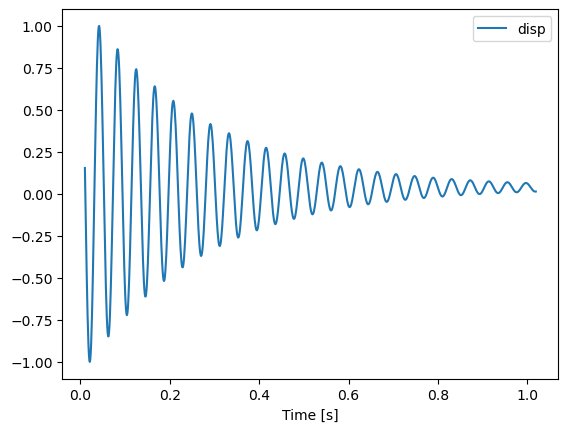

In [4]:
# --! simulate with parameters -----------------------------------------------!

sim_params = {
    'f_m'    : np.array([24.]), # 10, 24
    'q_m'    : np.array([20.]), # 20, 5
    't_m'    : np.array([[-1., -1.]]), # [dont care, dont care]
    't_rf_n' : 17,
    'dt'     : 0.001,
}

y24 = sim_detuning(sim_params)

print(f'inf >> time step for simulation is {sim_params['dt']:.4f}')
print(f'inf >> number of time steps is {len(y24.t)}')

# --! condition simulated data -----------------------------------------------!

# --! sum detuning
disp_m24 = np.zeros_like(y24.y[2])
for i in range(modes_m_n):
    disp_m24 = disp_m24 + y24.y[2 + 2*i]

# --! we want to skip the transient process of an RF cavity when scaling data
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# --! scale states
x_m24      = np.vstack([disp_m24[start_i:]]).T
x_scaler   = minmax_scaler(feature_range=(-1, 1))
x_m24_sca  = x_scaler.fit_transform(x_m24)

print(f'inf >> scaled states shape is {x_m10_sca.shape}')

plt.figure()
plt.plot(y24.t[start_i:], x_m24_sca[:, 0], label='disp')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

inf >> number of mechanical modes specified: 2
inf >> time step for simulation is 0.0010
inf >> number of time steps is 1020
inf >> starting index to skip a transient process is 10
inf >> scaled states shape is (1010, 1)


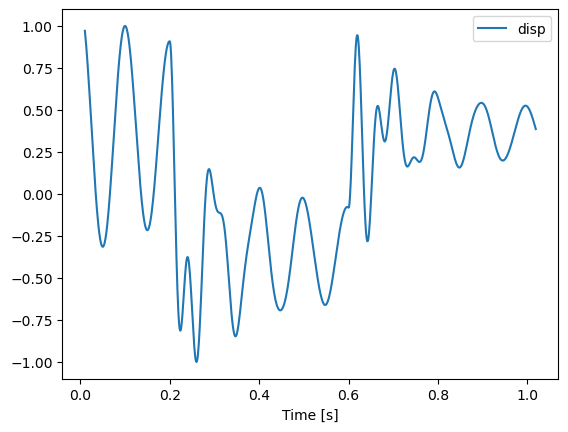

In [5]:
# --! simulate with parameters -----------------------------------------------!

sim_params = {
    'f_m'    : np.array([10., 24.]), # 10, 24
    'q_m'    : np.array([20., 5.]), # 20, 5
    't_m'    : np.array([[-1., -1.], [0.2, 0.6]]),
    't_rf_n' : 17,
    'dt'     : 0.001,
}

y10_24 = sim_detuning(sim_params)

print(f'inf >> time step for simulation is {sim_params['dt']:.4f}')
print(f'inf >> number of time steps is {len(y10_24.t)}')

# --! condition simulated data -----------------------------------------------!

# --! sum detuning
disp_m10_24 = np.zeros_like(y10_24.y[2])
for i in range(modes_m_n):
    disp_m10_24 = disp_m10_24 + y10_24.y[2 + 2*i]

# --! we want to skip the transient process of an RF cavity when scaling data
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# --! scale states
x_m10_24      = np.vstack([disp_m10_24[start_i:]]).T
x_scaler      = minmax_scaler(feature_range=(-1, 1))
x_m10_24_sca  = x_scaler.fit_transform(x_m10_24)

print(f'inf >> scaled states shape is {x_m10_24_sca.shape}')

plt.figure()
plt.plot(y10_24.t[start_i:], x_m10_24_sca[:, 0], label='disp')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

inf >> number of mechanical modes specified: 2
inf >> time step for simulation is 0.0010
inf >> number of time steps is 1020
inf >> starting index to skip a transient process is 10
inf >> scaled states shape is (1010, 1)


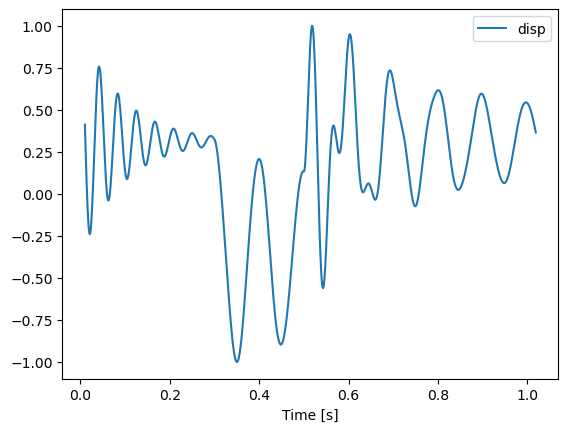

In [6]:
# --! simulate with parameters -----------------------------------------------!

sim_params = {
    'f_m'    : np.array([10., 24.]), # 10, 24
    'q_m'    : np.array([20., 7.]), # 20, 5
    't_m'    : np.array([[0.3, -1.], [-1., 0.5]]),
    't_rf_n' : 17,
    'dt'     : 0.001,
}

y24_10 = sim_detuning(sim_params)

print(f'inf >> time step for simulation is {sim_params['dt']:.4f}')
print(f'inf >> number of time steps is {len(y24_10.t)}')

# --! condition simulated data -----------------------------------------------!

# --! sum detuning
disp_m24_10 = np.zeros_like(y24_10.y[2])
for i in range(modes_m_n):
    disp_m24_10 = disp_m24_10 + y24_10.y[2 + 2*i]

# --! we want to skip the transient process of an RF cavity when scaling data
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# --! scale states
x_m24_10      = np.vstack([disp_m24_10[start_i:]]).T
x_scaler      = minmax_scaler(feature_range=(-1, 1))
x_m24_10_sca  = x_scaler.fit_transform(x_m24_10)

print(f'inf >> scaled states shape is {x_m24_10_sca.shape}')

plt.figure()
plt.plot(y24_10.t[start_i:], x_m24_10_sca[:, 0], label='disp')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

inf >> number of mechanical modes specified: 2
inf >> time step for simulation is 0.0010
inf >> number of time steps is 1020
inf >> starting index to skip a transient process is 10
inf >> scaled states shape is (1010, 1)


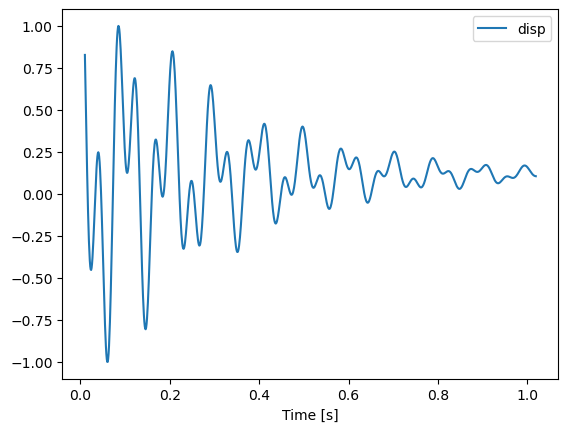

In [7]:
# --! simulate with parameters -----------------------------------------------!

sim_params = {
    'f_m'    : np.array([10., 24.]), # 10, 24
    'q_m'    : np.array([10., 20.]), # 20, 5
    't_m'    : np.array([[-1., -1.], [-1., -1.]]),
    't_rf_n' : 17,
    'dt'     : 0.001,
}

y10_24_sum = sim_detuning(sim_params)

print(f'inf >> time step for simulation is {sim_params['dt']:.4f}')
print(f'inf >> number of time steps is {len(y10_24_sum.t)}')

# --! condition simulated data -----------------------------------------------!

# --! sum detuning
disp_m10_24_sum = np.zeros_like(y10_24_sum.y[2])
for i in range(modes_m_n):
    disp_m10_24_sum = disp_m10_24_sum + y10_24_sum.y[2 + 2*i]

# --! we want to skip the transient process of an RF cavity when scaling data
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# --! scale states
x_m10_24_sum      = np.vstack([disp_m10_24_sum[start_i:]]).T
x_scaler          = minmax_scaler(feature_range=(-1, 1))
x_m10_24_sum_sca  = x_scaler.fit_transform(x_m10_24_sum)

print(f'inf >> scaled states shape is {x_m10_24_sum_sca.shape}')

plt.figure()
plt.plot(y10_24.t[start_i:], x_m10_24_sum_sca[:, 0], label='disp')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

In [8]:
# --! save simulation data to files ------------------------------------------!

def sample_timeseries(rng, sample_sz, timeseries_sz, *timeseries_array):
    """
    Given ``timeseries`` are expected to be shaped as one-dimensional arrays [T],
    where T is the number of timesteps.
    """

    # --! select current timeseries
    global timeseries_i
    # take the current timeseries using available index
    timeseries = timeseries_array[timeseries_i]

    # update timeseries index for the next time
    timeseries_i_end = len(timeseries_array) - 1
    if timeseries_i < timeseries_i_end:
        timeseries_i = timeseries_i + 1
    else:
        timeseries_i = 0

    # --! randomly locate a suitable sample region inside selected timeseries
    sample_start = int((timeseries_sz - sample_sz) * rng.random())
    sample_end   = sample_start + sample_sz
    sample       = timeseries[sample_start:sample_end, np.newaxis]

    # --! return a sample with mean removed
    return sample - np.mean(sample, axis=0, keepdims=True)

savedata_train_on = True

if savedata_train_on:

    dataset_dir = 'cavity/train_24Hz_10Hz_trans'

    savedata_config = [
        # batch size, file name
        (3500, 'train1'),
        (3500, 'train2'),
        (3500, 'train3'),
        (3500, 'train4'),
        (3500, 'train5'),
        (3500, 'train6'),
        (3500, 'train7'),
        (1000, 'valid'),
        (500,  'test')]

    savedata_sz = 200
    timeseries_sz = len(x_m10_sca[:, 0])

    if savedata_sz < timeseries_sz:

        for this, cfg in enumerate(savedata_config):

            rng = np.random.default_rng(seed=this + 1)
            timeseries_i = 0

            data = np.stack([
                sample_timeseries(
                    rng,
                    savedata_sz,
                    timeseries_sz,
                    x_m10_24_sca[:timeseries_sz, 0],
                    x_m24_10_sca[:timeseries_sz, 0]) for _ in range(cfg[0])], axis=0)

            utils.write_datafile(f'{dataset_dir}/{cfg[1]}', data)
        print('inf >> training files saved')
    else:
        print('err >> saved data size must be less than timeseries size!')
else:
    print('wrn >> training file saving is switched off')


inf >> training files saved


In [9]:
savedata_eval_on = False

def nomean(x):
    return x - np.mean(x, axis=0, keepdims=True)

if savedata_eval_on:
    savedata_len = 200
    ts_len       = len(x_m_sca[:, 0])

    ts_slices_n = ts_len // savedata_len
    if ts_slices_n > 0:
        ts_len_saved = savedata_len * ts_slices_n

        timeseries = np.split(x_m_sca[:ts_len_saved, :1], ts_slices_n, axis=0)
        #ts_scaler = minmax_scaler(feature_range=(-1, 1))

        data = np.expand_dims(np.concatenate([nomean(ts) for ts in timeseries], axis=0), 0)

        dataset_dir = 'cavity/eval_10Hz_24Hz'
        filename = 'eval1'
        utils.write_datafile(f'{dataset_dir}/{filename}', data)

        print('inf >> evaluation files saved')
    else:
        print('err >> saved timeseries sizes do not match!')
else:
    print('wrn >> evaluation file saving is switched off')

wrn >> evaluation file saving is switched off
